# Analysis of Airplane Crashes and Fatalities up to 2023

This notebook covers:
- Data Import and Cleaning
- Exploratory Data Analysis (EDA)
- Statistical Analysis with SciPy
- Data Visualization
- Insights and Conclusions


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import zipfile

plt.rcParams['figure.figsize'] = (10,6)
sns.set_style("whitegrid")


## 1. Data Import and Cleaning

In [2]:

zip_path = "Airplane Crashes and Fatalities upto 2023.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    print(z.namelist())
    csv_file = z.namelist()[0]

    df = pd.read_csv(z.open(csv_file), encoding='latin1')

df.head()


['Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv']


,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,9/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,9/7/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,7/12/1912,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,8/6/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,9/9/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...


In [3]:

df.info()
df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   4998 non-null   object 
 1   Time                   3486 non-null   object 
 2   Location               4994 non-null   object 
 3   Operator               4988 non-null   object 
 4   Flight #               1329 non-null   object 
 5   Route                  4221 non-null   object 
 6   AC Type                4983 non-null   object 
 7   Registration           4724 non-null   object 
 8   cn/ln                  4330 non-null   object 
 9   Aboard                 4980 non-null   float64
 10  Aboard Passangers      4769 non-null   float64
 11  Aboard Crew            4772 non-null   float64
 12  Fatalities             4990 non-null   float64
 13  Fatalities Passangers  4756 non-null   float64
 14  Fatalities Crew        4757 non-null   float64
 15  Grou

,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
count,4998,3486,4994,4988,1329,4221,4983,4724,4330,4980.000000,4769.000000,4772.000000,4990.000000,4756.000000,4757.000000,4956.000000,4934
unique,4570,1060,4122,2264,880,3825,2463,4689,3818,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4839
top,8/31/1988,15:00,"Moscow, Russia",Aeroflot,-,Training,Douglas DC-3,49,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Crashed under unknown circumstances.
freq,4,38,17,255,36,93,333,3,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.195984,27.009017,4.479254,22.373547,19.053827,3.578516,1.719128,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.534788,44.111609,3.483859,35.061741,34.146127,3.167922,55.540273,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.000000,3.000000,2.000000,4.000000,1.000000,2.000000,0.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.000000,12.000000,4.000000,11.000000,8.000000,3.000000,0.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.000000,30.000000,6.000000,25.000000,21.000000,5.000000,0.000000,NaN


In [4]:

# Missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values


Flight #                 3669
Time                     1512
Route                     777
cn/ln                     668
Registration              274
Fatalities Passangers     242
Fatalities Crew           241
Aboard Passangers         229
Aboard Crew               226
Summary                    64
Ground                     42
Aboard                     18
AC Type                    15
Operator                   10
Fatalities                  8
Location                    4
Date                        0
dtype: int64

In [5]:

# Date conversion
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Create time dimensions
df['Year'] = df['Date'].dt.year
df['Decade'] = (df['Year'] // 10) * 10

# Numeric columns
numeric_cols = [
    'Aboard',
    'Aboard Passangers',
    'Aboard Crew',
    'Fatalities',
    'Fatalities Passangers',
    'Fatalities Crew',
    'Ground'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Survival Rate
df['Survivors'] = df['Aboard'] - df['Fatalities']
df['Survival_Rate'] = np.where(
    df['Aboard'] > 0,
    (df['Survivors'] / df['Aboard']) * 100,
    np.nan
)

df.head()


,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,...,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary,Year,Decade,Survivors,Survival_Rate
0,1908-09-17,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,...,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly...",1908,1900,1.0,50.0
1,1909-09-07,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,...,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...,1909,1900,0.0,0.0
2,1912-07-12,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,...,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...,1912,1910,0.0,0.0
3,1913-08-06,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,...,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...,1913,1910,0.0,0.0
4,1913-09-09,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,...,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...,1913,1910,6.0,30.0


## 2. Exploratory Data Analysis

In [6]:

total_crashes = len(df)
total_fatalities = df['Fatalities'].sum()
avg_survival_rate = df['Survival_Rate'].mean()

print("Total crashes:", total_crashes)
print("Total fatalities:", total_fatalities)
print("Average survival rate:", round(avg_survival_rate,2), "%")


Total crashes: 4998
Total fatalities: 111644.0
Average survival rate: 18.15 %


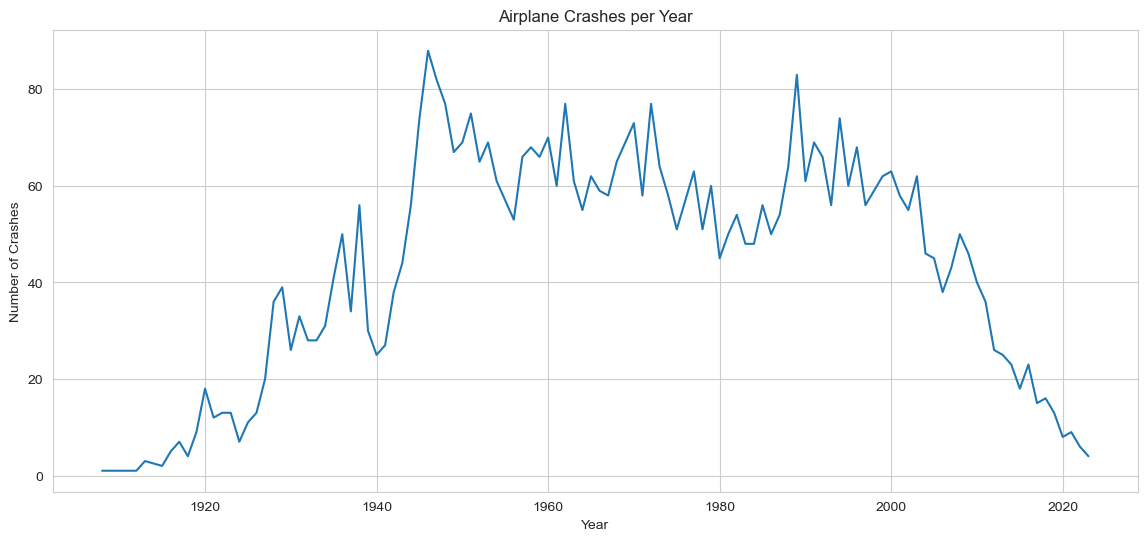

In [7]:

crashes_per_year = df.groupby('Year').size()

plt.figure(figsize=(14,6))
crashes_per_year.plot()
plt.title("Airplane Crashes per Year")
plt.xlabel("Year")
plt.ylabel("Number of Crashes")
plt.show()


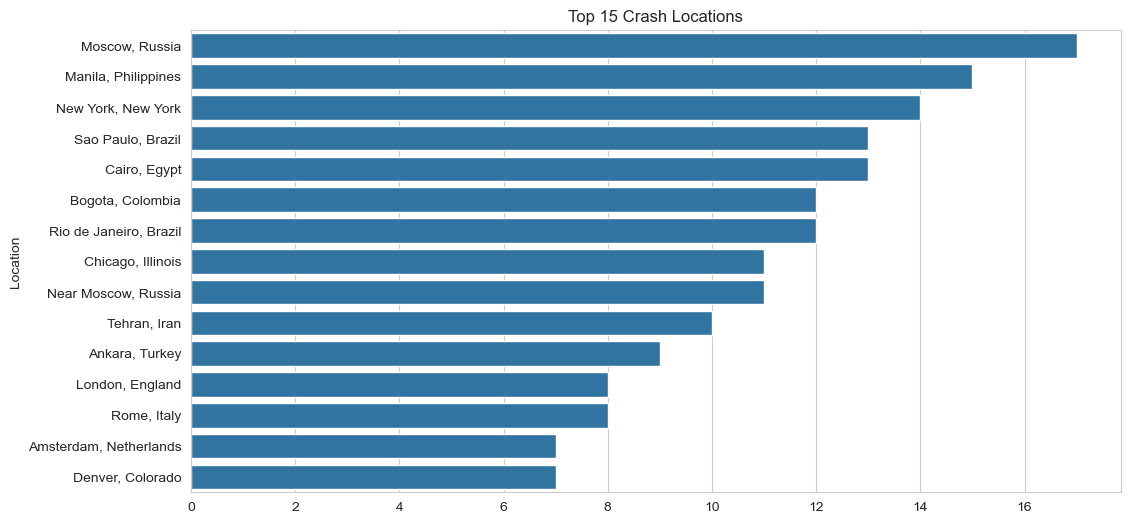

In [8]:

top_locations = df['Location'].value_counts().head(15)

plt.figure(figsize=(12,6))
sns.barplot(x=top_locations.values, y=top_locations.index)
plt.title("Top 15 Crash Locations")
plt.show()


## 3. Statistical Analysis using SciPy

In [9]:

fatalities = df['Fatalities'].dropna()

print("Mean:", fatalities.mean())
print("Median:", fatalities.median())
print("Standard Deviation:", fatalities.std())


Mean: 22.37354709418838
Median: 11.0
Standard Deviation: 35.06174065974314


In [10]:

# Normality test
stat, p = stats.normaltest(fatalities)

print("Statistic:", stat)
print("P-value:", p)

if p < 0.05:
    print("Distribution is NOT normal")
else:
    print("Distribution appears normal")


Statistic: 4822.517774190255
P-value: 0.0
Distribution is NOT normal


In [11]:

# Compare fatalities between decades

decade_1 = df[df['Decade'] < 1980]['Fatalities'].dropna()
decade_2 = df[df['Decade'] >= 1980]['Fatalities'].dropna()

t_stat, p_value = stats.ttest_ind(
    decade_1,
    decade_2,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Significant difference between decades")
else:
    print("No significant difference")


T-statistic: -5.737859760731833
P-value: 1.0562046515148078e-08
Significant difference between decades


## 4. Visualizations

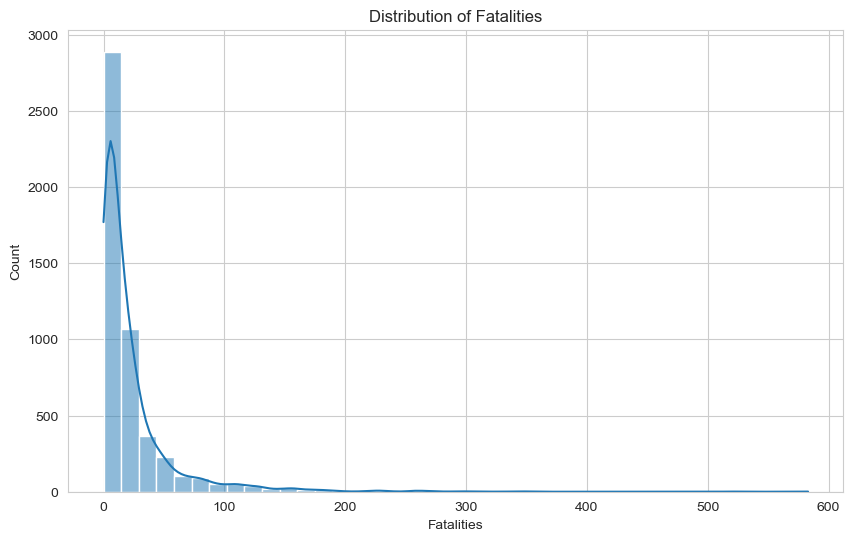

In [12]:

plt.figure(figsize=(10,6))
sns.histplot(df['Fatalities'], bins=40, kde=True)
plt.title("Distribution of Fatalities")
plt.show()


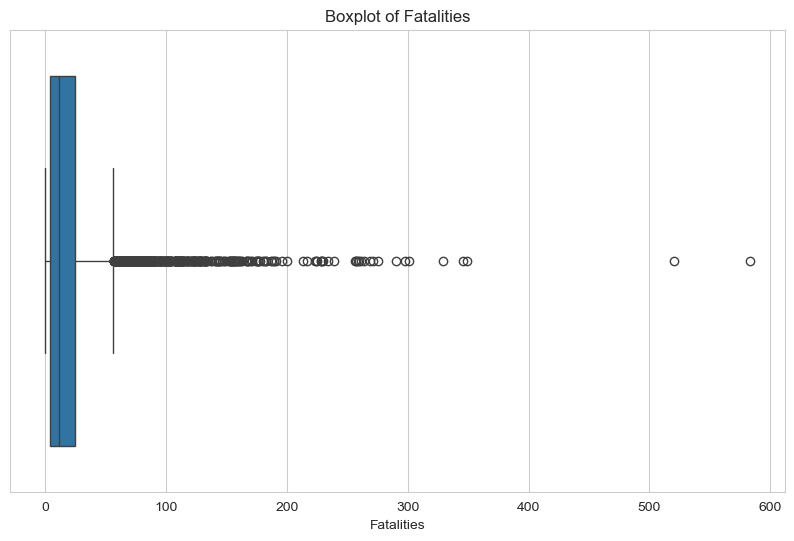

In [13]:

plt.figure(figsize=(10,6))
sns.boxplot(x=df['Fatalities'])
plt.title("Boxplot of Fatalities")
plt.show()


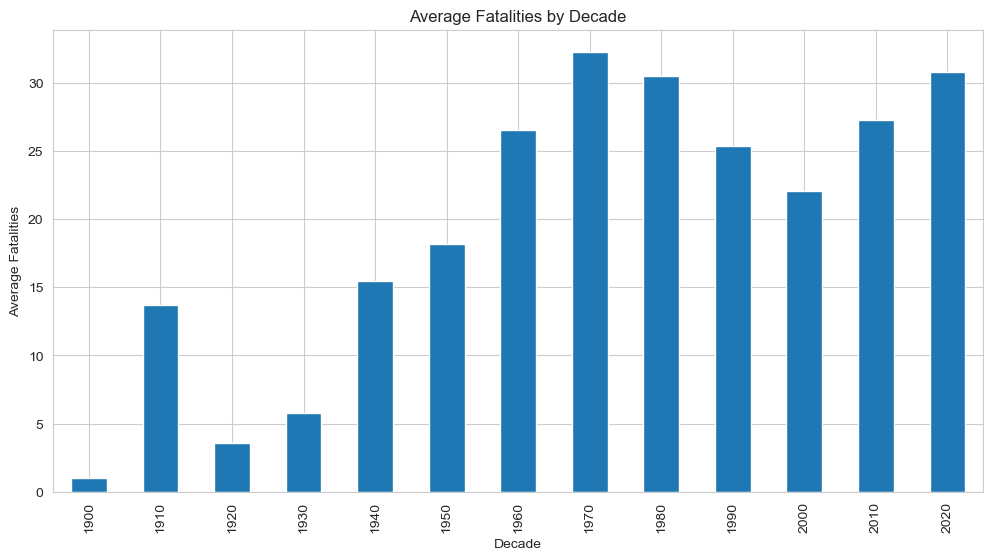

In [14]:

decade_stats = df.groupby('Decade')['Fatalities'].mean()

plt.figure(figsize=(12,6))
decade_stats.plot(kind='bar')
plt.title("Average Fatalities by Decade")
plt.ylabel("Average Fatalities")
plt.show()


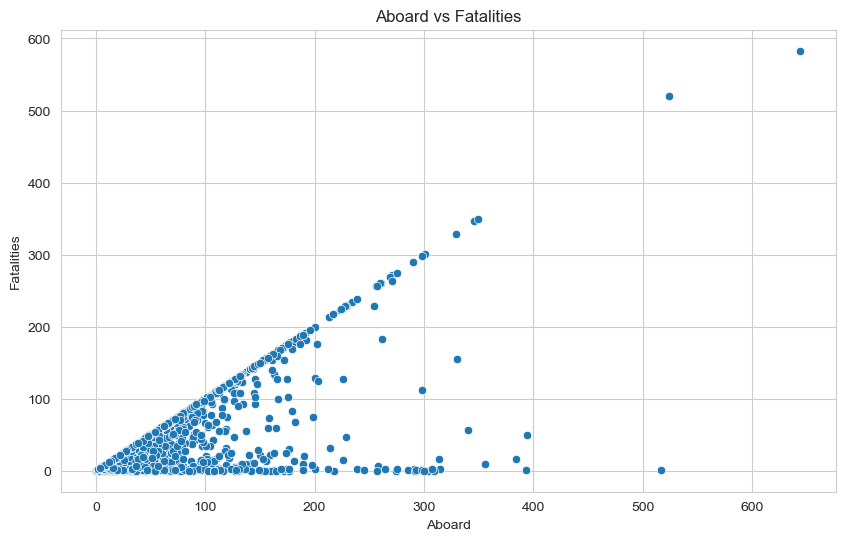

In [15]:

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Aboard',
    y='Fatalities'
)
plt.title("Aboard vs Fatalities")
plt.show()



## 5. Insights and Report

### Key Findings

1. The dataset contains historical airplane crashes from 1908 to 2023.
2. Crash frequency varies significantly across decades.
3. Fatalities show a highly skewed distribution.
4. Statistical testing can reveal whether fatality patterns changed over time.
5. Survival rates vary substantially depending on crash severity.

### Technologies Used

- Pandas → data loading, cleaning, transformation
- NumPy → numerical calculations
- SciPy → statistical testing
- Matplotlib → plotting
- Seaborn → advanced visualizations

### Conclusion

This analysis provides a complete workflow for cleaning, exploring, visualizing, and statistically analyzing airplane crash data. Additional investigations could include airline-specific risk analysis, geographic clustering, and predictive modeling.
